In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
import h5py
import numpy as np
import copy
from functions import * 


def load_obj(name):
    with open('bestfits/' + name + '.pkl', 'rb') as f:
        obj = pickle.load(f)
        print(name+':')
        if 'varied' in name:
            for z in obj.keys():
                print('z = '+z)
                p1, p2, p3, p4, p5, p6 = obj[z]['Transition point'], obj[z]['Pre-disk slope'],\
                                         obj[z]['Pre-disk normalization'], obj[z]['Pre-disk sigma'],\
                                         obj[z]['Post-disk sigma'], obj[z]['Post-disk normalization']
                print(z+' & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
                print('\n')
        else:
            p1, p2, p3, p4, p5, p6 = obj['Transition point'], obj['Pre-disk slope'],\
                                     obj['Pre-disk normalization'], obj['Pre-disk sigma'],\
                                     obj['Post-disk sigma'], obj['Post-disk normalization']
            print('ALL & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
            print('\n')
        return obj

## Testing ranges of parameters to explore.

In [3]:
r1, r2, r3, r4, r5, r6 = 30, 30, 30, 1, 30, 30

logMstar0 = np.linspace(8.0,12.0, r1)
xsigpre = np.linspace(0.1,5.0,r2)
xsigpost = np.linspace(0.1,5.0,r3)
slopes = np.linspace(1,1,r4)
norms = np.linspace(0.01,4.0,r5)
local_norms = np.linspace(-3.5, -1.5, r6)
print('logMstar:', logMstar0)
print('alpha:', slopes)
print('log10gamma:', norms)
print('log10beta:', local_norms)

logMstar: [ 8.          8.13793103  8.27586207  8.4137931   8.55172414  8.68965517
  8.82758621  8.96551724  9.10344828  9.24137931  9.37931034  9.51724138
  9.65517241  9.79310345  9.93103448 10.06896552 10.20689655 10.34482759
 10.48275862 10.62068966 10.75862069 10.89655172 11.03448276 11.17241379
 11.31034483 11.44827586 11.5862069  11.72413793 11.86206897 12.        ]
alpha: [1.]
log10gamma: [0.01       0.14758621 0.28517241 0.42275862 0.56034483 0.69793103
 0.83551724 0.97310345 1.11068966 1.24827586 1.38586207 1.52344828
 1.66103448 1.79862069 1.9362069  2.0737931  2.21137931 2.34896552
 2.48655172 2.62413793 2.76172414 2.89931034 3.03689655 3.17448276
 3.31206897 3.44965517 3.58724138 3.72482759 3.86241379 4.        ]
log10beta: [-3.5        -3.43103448 -3.36206897 -3.29310345 -3.22413793 -3.15517241
 -3.0862069  -3.01724138 -2.94827586 -2.87931034 -2.81034483 -2.74137931
 -2.67241379 -2.60344828 -2.53448276 -2.46551724 -2.39655172 -2.32758621
 -2.25862069 -2.18965517 -2.120689

## Generating null grids to invoke any priors.

In [ ]:
def get_null(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]]:# or transition[index[5]] > 10.:#alpha[index[2]] > 1 or alpha[index[2]] < 0.5:
            chi2_grid[index] = 1e6

    null = np.where(chi2_grid == 1e6)
    
    return null

def get_null_alpha1(FILE):
    f = h5py.File(FILE, "r") 
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    alpha = f['slope_low'][:]
    transition = f['logMstar0'][:]
    chi2_grid = f['chi2_grid'][:].T
    f.close()

    for index, value in np.ndenumerate(chi2_grid):
        if siglnX2[index[3]] > siglnX1[index[4]] or alpha[index[2]] != 1.06:
            chi2_grid[index] = 1e6

    null = np.where(chi2_grid == 1e6)
    
    return null

redshifts = [0.5, 1.0, 2.0, 3.0, 4.0]
filename = '../ceph/QLF_proj/output/chi2_2P'

print('Generating null grids.')
null = get_null(filename+'_z'+str(redshifts[0])+'.h5py')
print('done')
null_alpha1 = get_null_alpha1(filename+'_z'+str(redshifts[0])+'.h5py')
print('done')

Generating null grids.


## Finding the total number of observation points.

In [7]:
print(np.shape(null),np.shape(null_alpha1))
num_of_points = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}

fobs = h5py.File("SHEN_obs_collect.h5py", "r")
for z in [0.5,1.0,2.0,3.0,4.0]:
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        num_of_points['z='+str(z)] += len(x)
        num_of_points['fixed'] += len(x)
fobs.close()
print(num_of_points)

num_of_points_phantom = {'z=0.5':0,'z=1.0':0,'z=2.0':0,'z=3.0':0,'z=4.0':0, 'fixed':0}
for z in [0.5,1.0,2.0,3.0,4.0]:
    xtot = []
    ya = []
    yaerr = []
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
        ya.extend(fobs[index]['y'][:]) ##log10 of QLF
        yaerr.extend(fobs[index]['yerr'][:]) ##error on that
    fobs.close()

    xobscut = min(np.asarray(xtot))
    xphan = np.linspace(40, 44, 9)
    if round(xobscut) < xobscut:
        xphan = xphan[xphan <= round(xobscut)]
    else:
        xphan = xphan[xphan < round(xobscut)]
    num_of_points_phantom['z='+str(z)] += len(xphan)
    num_of_points_phantom['fixed'] += len(xphan)
print(num_of_points_phantom)    

totpoints = num_of_points_phantom['fixed']+num_of_points['fixed']

print('Total number of points fit:',totpoints)


(6, 30400000) (6, 62320000)
{'z=0.5': 174, 'z=1.0': 176, 'z=2.0': 177, 'z=3.0': 146, 'z=4.0': 83, 'fixed': 756}
{'z=0.5': 3, 'z=1.0': 4, 'z=2.0': 6, 'z=3.0': 8, 'z=4.0': 8, 'fixed': 29}
Total number of points fit: 785


## Finding best fit values.

In [ ]:
bulge=False

print('Combining grids.')
for z in redshifts:
    f = h5py.File(filename+'_z'+str(z)+'.h5py', "r") 
    if bulge:
        transition = f['logMb0'][:]
    else:
        transition = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    norm_of_local = f['norm_of_local'][:]
    if z == redshifts[0]:
        chi2_grid = f['chi2_grid'][:].T
    else:
        chi2_grid += f['chi2_grid'][:].T
    f.close()

# print('Setting up the probability density.')

# dtran = transition[1]-transition[0]
# dslope = slope_low[1]-slope_low[0]
# dnorm = norm_of_local[1]-norm_of_local[0]
# dbreak = norm_from_local[1]-norm_from_local[0]
# dsig1 = siglnX1[1]-siglnX1[0]
# dsig2 = siglnX2[1]-siglnX2[0]
# dx6 = dtran*dslope*dnorm*dbreak*dsig1*dsig2

reduced_chi2 = chi2_grid/totpoints
reduced_chi2_alpha1 = chi2_grid/totpoints
print('Setting null points.')
reduced_chi2[null] = 1e6
reduced_chi2_alpha1[null_alpha1] = 1e6

# propto = np.exp(-reduced_chi2)/dx6
# propto[null] = 0.

# print('Normalizing probability distribution.')
# c = 1/np.sum(propto*dx6, axis=(0,1,2,3,4,5))
# P = c*propto

print('Finding best fit values.')
minval = np.amin(reduced_chi2)
minind = np.where(reduced_chi2 == minval)

print('chi2 reduced =', minval)

beta_fit = norm_of_local[minind[0][0]] 
gamma_fit = norm_from_local[minind[1][0]]
alpha_fit = slope_low[minind[2][0]]
post_fit = siglnX2[minind[3][0]]
pre_fit = siglnX1[minind[4][0]]
crit_fit = transition[minind[5][0]]  

minval_alpha1 = np.amin(reduced_chi2_alpha1)
minind_alpha1 = np.where(reduced_chi2_alpha1 == minval_alpha1)

print('chi2 reduced (alpha1) =', minval_alpha1)

beta_fit_alpha1 = norm_of_local[minind_alpha1[0][0]] 
gamma_fit_alpha1 = norm_from_local[minind_alpha1[1][0]]
alpha_fit_alpha1 = slope_low[minind_alpha1[2][0]]
post_fit_alpha1 = siglnX2[minind_alpha1[3][0]]
pre_fit_alpha1 = siglnX1[minind_alpha1[4][0]]
crit_fit_alpha1 = transition[minind_alpha1[5][0]]  

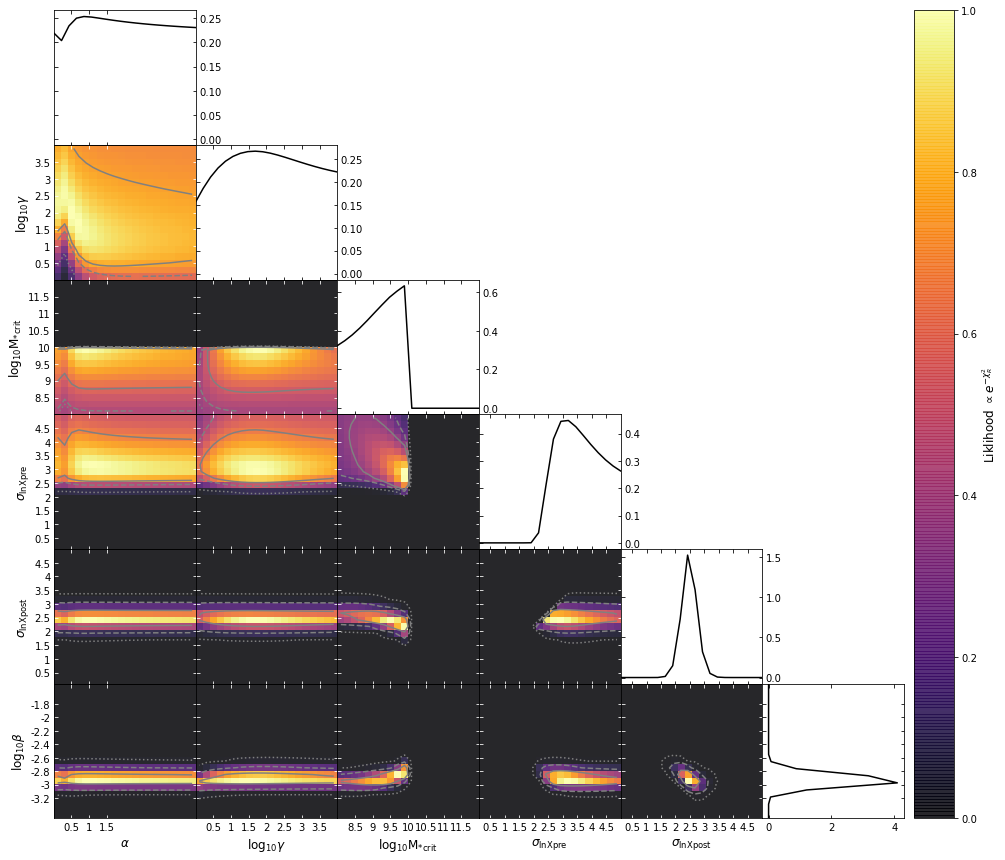

In [134]:
plt.close('all')
axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
axi = [5,5,5,5,5,4,4,4,4,3,3,3,2,2,1]
axes_l = []
props = dict(boxstyle='square', facecolor='white', alpha=1)

extents = [\
           [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [slope_low[0], slope_low[-1], transition[-1], transition[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
           [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
          ]

# best_fits = [[alpha_fit,beta_fit],[gamma_fit,beta_fit],[crit_fit,beta_fit],[pre_fit,beta_fit],[post_fit,beta_fit],\
#             [alpha_fit,post_fit],[gamma_fit,post_fit],[crit_fit,post_fit],[pre_fit,post_fit],\
#             [alpha_fit,pre_fit],[gamma_fit,pre_fit],[crit_fit,pre_fit],\
#             [alpha_fit,crit_fit],[gamma_fit,crit_fit],\
#             [alpha_fit,gamma_fit]]
# best_fits2 = [[alpha_fit2,beta_fit2],[gamma_fit2,beta_fit2],[crit_fit2,beta_fit2],[pre_fit2,beta_fit2],[post_fit2,beta_fit2],\
#             [alpha_fit2,post_fit2],[gamma_fit2,post_fit2],[crit_fit2,post_fit2],[pre_fit2,post_fit2],\
#             [alpha_fit2,pre_fit2],[gamma_fit2,pre_fit2],[crit_fit2,pre_fit2],\
#             [alpha_fit2,crit_fit2],[gamma_fit2,crit_fit2],\
#             [alpha_fit2,gamma_fit2]]

bl = ''  
slopel = r'$\alpha$'
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
slopet = [ 0.5, 1, 1.5]#, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 

dxvalues = [dnorm, dbreak, dslope, dsig2, dsig1, dtran]

sums = [(1,3,4,5),(2,3,4,5),(1,2,3,4),(1,2,3,5),(1,2,4,5),\
        (0,1,4,5),(0,2,4,5),(0,1,2,4),(0,1,2,5),\
        (0,1,3,5),(0,2,3,5),(0,1,2,3),\
        (0,1,3,4),(0,2,3,4),\
        (0,3,4,5)]

'''
plots: alpha-beta, gamma-beta, crit-beta, presig-beta, postsig-beta
       alpha-postsig, gamma-postsig, crit-postsig, presig-postsig
       alpha-presig, gamma-presig, crit-presig
       alpha-crit, gamma-crit
       alpha-gamma

beta = 0
gamma = 1
alpha = 2
postsig = 3
presig = 4
crit = 5
'''

transpose = [0,0,0,0,0,1,1,0,0,1,1,0,1,1,0]

inds = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(6, 6)
axes_l = []

for ind, i, j, s in zip(inds, axi, axj, sums):   

    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
    
    dx4 = dxvalues[s[0]]*dxvalues[s[1]]*dxvalues[s[2]]*dxvalues[s[3]]
    grid2d = np.sum(P*dx4, axis=s)
    
    grid2d = grid2d/np.amax(grid2d)
    
    if transpose[ind]:
        grid2d = grid2d.T
    
    sortedgrid = sorted(grid2d.reshape(1, len(grid2d[0,:])*len(grid2d[:,0]))[0])[::-1]
    cumulative = np.cumsum(sortedgrid)
    cumnorm = cumulative/max(cumulative)
    sig1, sig2, sig3 = 0.68, 0.95, 0.997
    sigmas = []
    for sig in [sig3, sig2, sig1]:
        close = min(np.abs(cumnorm - sig))
        where = np.where(np.abs(cumnorm - sig) == close)[0][0]
        sigma = sortedgrid[where]
        sigmas.append(sigma)

    norm = colors.Normalize(vmin = 0, vmax = 1)

    cmap = copy.copy(matplotlib.cm.get_cmap('inferno'))
    cmap.set_bad(color='gray')
    img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    cont = ax.contour(grid2d, colors = ['grey', 'grey', 'grey'], linestyles = ['dotted', 'dashed', 'solid'], origin = 'image', linewidths=1.5, levels=sigmas, extent = extent, norm=norm)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')
    
plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[10].get_xticklabels(), visible=False)
plt.setp(axes_l[11].get_xticklabels(), visible=False)
plt.setp(axes_l[12].get_xticklabels(), visible=False)
plt.setp(axes_l[13].get_xticklabels(), visible=False)
plt.setp(axes_l[14].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[4].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[7].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)
plt.setp(axes_l[10].get_yticklabels(), visible=False)
plt.setp(axes_l[11].get_yticklabels(), visible=False)
plt.setp(axes_l[13].get_yticklabels(), visible=False)
    
axj = [0,1,2,3,4,5]
axi = [0,1,2,3,4,5]
# best_fits = [alpha_fit, gamma_fit, crit_fit, pre_fit, post_fit, beta_fit]
# best_fits2 = [alpha_fit2, gamma_fit2, crit_fit2, pre_fit2, post_fit2, beta_fit2]
ranges = [slope_low, norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
sums = [(0,1,3,4,5), (0,2,3,4,5), (0,1,2,3,4), (0,1,2,3,5), (0,1,2,4,5), (1,2,3,4,5)]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[4], axes_l[0]]
for ind, i, j, s in zip(inds, axi, axj, sums):
    dx5 = dxvalues[s[0]]*dxvalues[s[1]]*dxvalues[s[2]]*dxvalues[s[3]]*dxvalues[s[4]]
    P1D = np.sum(P*dx5, axis=s)
    
    if ind != 5:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        ax.plot(ranges[ind], P1D,c='k')
        ax.set_ylim([0-max(P1D)/20,max(P1D)+max(P1D)/20])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')

        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        ax.plot(P1D, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(P1D)/20,max(P1D)+max(P1D)/20])
        plt.setp(ax.get_yticklabels(), visible=False)
        
    
    
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, label='Liklihood', pad = 0.01, ax = axes_l).set_label(label=r'Liklihood $\propto e^{-\chi^2_R}$',size=12)
    
plt.savefig('PLOTS/likelihood_phantom-fixed_lowres_mscrit8-10.pdf')

## Defining functions for plotting.

In [10]:
def plot_obs(ax, phantom = False):
    objs = []
    labels = []
    colors = {'B-Band':'pink', 'UV-1450A':'seagreen', 'Hard-X':'royalblue', 'Soft-X':'grey', 'Mid-IR':'olive'}
    cleanlabel = {'B-Band':'B Band', 'UV-1450A':r'UV 1450$\rm\AA$', 'Hard-X':'Hard X-ray', 'Soft-X':'Soft X-ray', 'Mid-IR':'Mid IR'}
    cs, ms, lw, ct = 1.5, 2.5, 1, 1
    
    fobs = h5py.File("SHEN_obs_collect.h5py", "r")
    for band in fobs["z="+str(z)]:
        index = "z="+str(z)+"/"+band
        x = fobs[index]['x'][:]
        y = fobs[index]['y'][:]
        xerr = fobs[index]['xerr'][:]
        yerr = fobs[index]['yerr'][:]
        xerrcor = np.zeros((2,len(xerr)))
        xerrcor[1,:] = 10**(x + xerr) - 10**x
        xerrcor[0,:] = 10**x - 10**(x - xerr)

        b = ax.errorbar(10**x, y, yerr = yerr, c=colors[band], fmt = 'o', fillstyle='none', capsize=cs, ms=ms, lw=lw, capthick=ct, zorder=2, alpha = 1)
        objs.append(b)
        labels.append(cleanlabel[band])
    fobs.close()
    
    if phantom:
        xtot = []
        ya = []
        yaerr = []
        fobs = h5py.File("SHEN_obs_collect.h5py", "r")
        for band in fobs["z="+str(z)]:
            index = "z="+str(z)+"/"+band
            xtot.extend(fobs[index]['x'][:]) ##log10 of bolometric L in erg/s
            ya.extend(fobs[index]['y'][:]) ##log10 of QLF
            yaerr.extend(fobs[index]['yerr'][:]) ##error on that
        fobs.close()

        xobscut = min(np.asarray(xtot))
        xphan = np.linspace(40, 44, 9)
        if round(xobscut) < xobscut:
            xphan = xphan[xphan <= round(xobscut)]
        else:
            xphan = xphan[xphan < round(xobscut)]
        yphan, yphanerr, _, _, _ = Shen_fit_uncer(z, np.log10(10**xphan/3.8e33))

        p = ax.errorbar(10**xphan, yphan, yerr = yphanerr, c='cyan', fmt = 'o', fillstyle='none',  capsize=cs, ms=ms, lw=lw, capthick=ct,  zorder=2)
        objs.append(p)
        labels.append('Phantom points')

    return objs, labels

# Plotting the 6 parameter space.

/mnt/home/mtillman/miniconda3/envs/spectra/lib/python3.7/site-packages/ipykernel_launcher.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


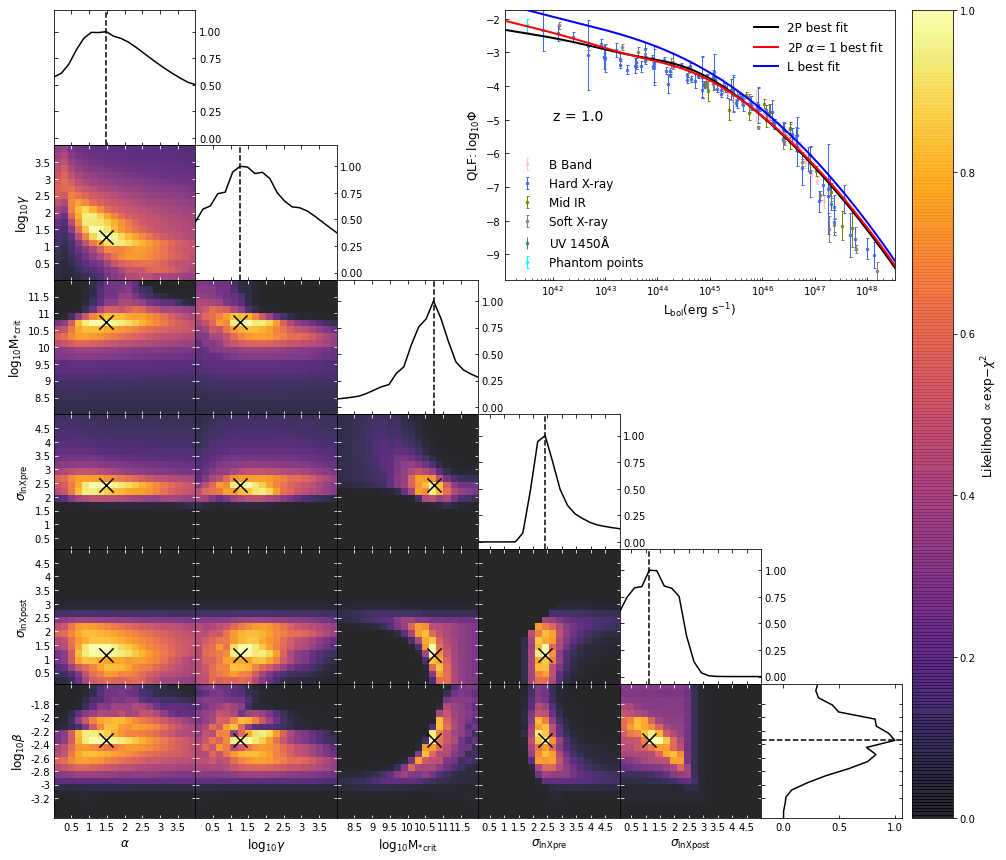

In [45]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(6, 6)

likelihood = np.exp(-reduced_chi2)

axj = [0,1,2,3,4,0,1,2,3,0,1,2,0,1,0]
axi = [5,5,5,5,5,4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [\
           [slope_low[0], slope_low [-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [slope_low[0], slope_low[-1], transition[-1], transition[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
           [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]\
          ]

bl = ''  
slopel = r'$\alpha$'
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [slopel, norml, critl, prel, postl, bl, bl, bl, bl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, bl, postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
slopet = [ 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [slopet, normt, critt, pret, postt, slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
yticks = [localt, localt, localt, localt, localt, postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
best_fits = [[alpha_fit,beta_fit],[gamma_fit,beta_fit],[crit_fit,beta_fit],[pre_fit,beta_fit],[post_fit,beta_fit],\
            [alpha_fit,post_fit],[gamma_fit,post_fit],[crit_fit,post_fit],[pre_fit,post_fit],\
            [alpha_fit,pre_fit],[gamma_fit,pre_fit],[crit_fit,pre_fit],\
            [alpha_fit,crit_fit],[gamma_fit,crit_fit],\
            [alpha_fit,gamma_fit]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,0,:,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, j, :, :,:])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,:,:,0,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,0,:,0,:,0].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 10:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 11:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj

    elif ind == 12:
        chi2_proj = np.zeros(chi23d[0,0,:,0,0,:].shape)
        for i in range(len(chi23d[0,0,:,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, i, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 13:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T

    elif ind == 14: 
        chi2_proj = np.zeros(chi23d[0,:,:,0,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,:,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, j, :, :, :])
        grid2d = chi2_proj
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[10].get_xticklabels(), visible=False)
plt.setp(axes_l[11].get_xticklabels(), visible=False)
plt.setp(axes_l[12].get_xticklabels(), visible=False)
plt.setp(axes_l[13].get_xticklabels(), visible=False)
plt.setp(axes_l[14].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[4].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[7].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)
plt.setp(axes_l[10].get_yticklabels(), visible=False)
plt.setp(axes_l[11].get_yticklabels(), visible=False)
plt.setp(axes_l[13].get_yticklabels(), visible=False)


axj = [0,1,2,3,4,5]
axi = [0,1,2,3,4,5]
ranges = [slope_low, norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[4], axes_l[0]]
best_fits = [alpha_fit, gamma_fit, crit_fit, pre_fit, post_fit, beta_fit]
inds = [0,1,2,3,4,5]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,:,0,0,0].shape)
        for k in range(len(chi23d[0,0,:,0,0,0])):
            proj[k] = np.amax(chi23d[:,:,k,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 5:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 5:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15,max(proj)+max(proj)/5])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5,max(proj)+max(proj)/15])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')

        

gs2 = gridspec.GridSpec(6, 3)
gs2.update(left=0.55, right=0.98)
ax = fig.add_subplot(gs2[0:2,:])
axes_l.append(ax)

bins = 0.0005
z = 1.0
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

qlf = QLF(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = '2P best fit', lw=2, zorder=10)

qlf = QLF(z, bins)
qlf.get_Mbh(crit_fit_alpha1, alpha_fit_alpha1, gamma_fit_alpha1, norm_local = 11+beta_fit_alpha1)
qlf.get_dNdlnL(lums, [pre_fit_alpha1, post_fit_alpha1])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='r', label = r'2P $\alpha=1$ best fit', lw=2, zorder = 10)

qlf = QLF(z, bins)
qlf.get_Mbh(3, 1, 0, norm_local = 11-2.8)
qlf.get_dNdlnL(lums, [2.4, 2.4])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='b', label = r'L best fit', lw=2, zorder=10)


objs, labels = plot_obs(ax, phantom = True)

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
ax.text(10**42,-5,'z = '+str(z), fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0)
legendB = ax.legend(handles = objs, labels=labels, fontsize = 12, loc='lower left', framealpha=0)
ax.add_artist(legend)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('PLOTS/bivariate-likelihood_phantom-fixed_lowres.pdf')

# Plotting the 5 parameter space (set alpha = 1)

ValueError: NumPy boolean array indexing assignment cannot assign 19000 input values to the 0 output values where the mask is true

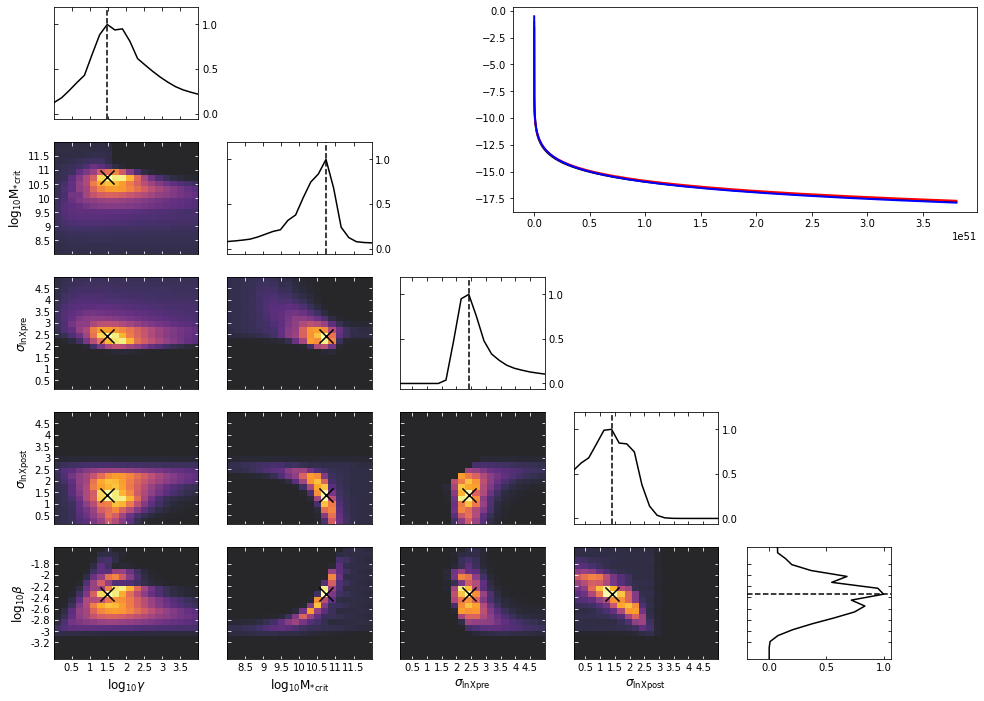

In [6]:
plt.close('all')


fig = plt.figure(figsize=(15,12))
gs = gridspec.GridSpec(5, 5)

likelihood = np.exp(-reduced_chi2_alpha1)

axj = [0,1,2,3,0,1,2,0,1,0]
axi = [4,4,4,4,3,3,3,2,2,1]
axes_l = []

extents = [[norm_from_local[0], norm_from_local[-1], norm_of_local[-1], norm_of_local[0]],\
           [transition[0], transition[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX1[0], siglnX1[-1], norm_of_local[-1], norm_of_local[0]],\
           [siglnX2[0], siglnX2[-1], norm_of_local[-1], norm_of_local[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
           [transition[0], transition[-1], siglnX2[-1], siglnX2[0]],\
           [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
           [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
           [transition[0], transition[-1], siglnX1[-1], siglnX1[0]],\
           [norm_from_local[0], norm_from_local[-1], transition[-1], transition[0]],\
          ]

bl = ''  
norml = r'$\log_{10}\gamma$'
prel = r'$\sigma_{\ln{\rmXpre}}$'
postl = r'$\sigma_{\ln{\rmXpost}}$'
critl = r'$\log_{10}\rmM_{*crit}$'
locall = r'$\log_{10}\beta$'
xlabels = [norml, critl, prel, postl, bl, bl, bl, bl, bl, bl]
ylabels = [locall, bl, bl, bl, postl, bl, bl, prel, bl, critl]
slopet = [ 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
normt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]
pret = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
postt = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
localt = [-3.2, -3, -2.8, -2.6, -2.4, -2.2, -2, -1.8]
critt = [8.5, 9, 9.5, 10, 10.5, 11, 11.5]
xticks = [normt, critt, pret, postt, normt, critt, pret,normt, critt, normt]
yticks = [localt, localt, localt, localt, postt, postt, postt, pret, pret, critt] 
indices = [0,1,2,3,4,5,6,7,8,9]
best_fits = [[gamma_fit_alpha1,beta_fit_alpha1],[crit_fit_alpha1,beta_fit_alpha1],[pre_fit_alpha1,beta_fit_alpha1],[post_fit_alpha1,beta_fit_alpha1],\
            [gamma_fit_alpha1,post_fit_alpha1],[crit_fit_alpha1,post_fit_alpha1],[pre_fit_alpha1,post_fit_alpha1],\
            [gamma_fit_alpha1,pre_fit_alpha1],[crit_fit_alpha1,pre_fit_alpha1],\
            [gamma_fit_alpha1,crit_fit_alpha1]]
for ind, i, j in zip(indices, axi, axj):   
        
    ### set up axis and label info
    ylabel = ylabels[ind]
    xlabel = xlabels[ind]
    extent = extents[ind]

                     
    ax = fig.add_subplot(gs[i, j])
    axes_l += [ax]
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylabel(ylabel,fontsize=12)
    ax.axis([extents[ind][0],extents[ind][1],extents[ind][3],extents[ind][2]])

    plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
    ax.set_xticklabels([str(i) for i in xticks[ind]])
    ax.set_yticklabels([str(i) for i in yticks[ind]])
        
    chi23d = likelihood
    if ind == 0:
        chi2_proj = np.zeros(chi23d[:,:,0,0,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,:,0,0,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, j, :, :, :, :])
        grid2d = chi2_proj

    elif ind == 1:
        chi2_proj = np.zeros(chi23d[:,0,0,0,0,:].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, :, j])
        grid2d = chi2_proj

    elif ind == 2:
        chi2_proj = np.zeros(chi23d[:,0,0,0,:,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, :, j, :])
        grid2d = chi2_proj

    elif ind == 3:
        chi2_proj = np.zeros(chi23d[:,0,0,:,0,0].shape)
        for i in range(len(chi23d[:,0,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[i, :, :, j, :, :])
        grid2d = chi2_proj

    elif ind == 4:
        chi2_proj = np.zeros(chi23d[0,:,0,:,0,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,:,0,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, j, :, :])
        grid2d = chi2_proj.T

    elif ind == 5:
        chi2_proj = np.zeros(chi23d[0,0,0,:,0,:].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, :, j])
        grid2d = chi2_proj

    elif ind == 6:
        chi2_proj = np.zeros(chi23d[0,0,0,:,:,0].shape)
        for i in range(len(chi23d[0,0,0,:,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, i, j, :])
        grid2d = chi2_proj

    elif ind == 7:
        chi2_proj = np.zeros(chi23d[0,:,0,0,:,0].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,:,0])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, j, :])
        grid2d = chi2_proj.T

    elif ind == 8:
        chi2_proj = np.zeros(chi23d[0,0,0,0,:,:].shape)
        for i in range(len(chi23d[0,0,0,0,:,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, :, :, :, i, j])
        grid2d = chi2_proj


    elif ind == 9:
        chi2_proj = np.zeros(chi23d[0,:,0,0,0,:].shape)
        for i in range(len(chi23d[0,:,0,0,0,0])):
            for j in range(len(chi23d[0,0,0,0,0,:])):
                chi2_proj[i, j] = np.amax(chi23d[:, i, :, :, :, j])
        grid2d = chi2_proj.T
     
    vmax = 1
    norm = colors.Normalize(vmin = 0, vmax = vmax)

    cmap = matplotlib.cm.get_cmap('inferno')
    img = ax.imshow(grid2d/np.amax(grid2d), cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, alpha=0.85)
    ax.scatter(best_fits[ind][0], best_fits[ind][1], marker = 'x', c='k', s=200)
    ax.tick_params(axis='both', direction='in',top=True,right=True,color='white')

plt.setp(axes_l[5].get_xticklabels(), visible=False)
plt.setp(axes_l[6].get_xticklabels(), visible=False)
plt.setp(axes_l[7].get_xticklabels(), visible=False)
plt.setp(axes_l[8].get_xticklabels(), visible=False)
plt.setp(axes_l[9].get_xticklabels(), visible=False)
plt.setp(axes_l[4].get_xticklabels(), visible=False)

plt.setp(axes_l[1].get_yticklabels(), visible=False)
plt.setp(axes_l[2].get_yticklabels(), visible=False)
plt.setp(axes_l[3].get_yticklabels(), visible=False)
plt.setp(axes_l[5].get_yticklabels(), visible=False)
plt.setp(axes_l[6].get_yticklabels(), visible=False)
plt.setp(axes_l[8].get_yticklabels(), visible=False)


axj = [0,1,2,3,4]
axi = [0,1,2,3,4]
ranges = [norm_from_local, transition, siglnX1, siglnX2, norm_of_local]
share = [axes_l[0], axes_l[1], axes_l[2], axes_l[3], axes_l[0]]
best_fits = [gamma_fit_alpha1, crit_fit_alpha1, pre_fit_alpha1, post_fit_alpha1, beta_fit_alpha1]
inds = [0,1,2,3,4]

for ind, i, j in zip(inds, axi, axj):    
    if ind == 0:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,:,0,0,0,0].shape)
        for k in range(len(chi23d[0,:,0,0,0,0])):
            proj[k] = np.amax(chi23d[:,k,:,:,:,:])
    elif ind == 1:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,0,:].shape)
        for k in range(len(chi23d[0,0,0,0,0,:])):
            proj[k] = np.amax(chi23d[:,:,:,:,:,k])
    elif ind == 2:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,0,:,0].shape)
        for k in range(len(chi23d[0,0,0,0,:,0])):
            proj[k] = np.amax(chi23d[:,:,:,:,k,:])
    elif ind == 3:
        ax = fig.add_subplot(gs[i, j],sharex = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[0,0,0,:,0,0].shape)
        for k in range(len(chi23d[0,0,0,:,0,0])):
            proj[k] = np.amax(chi23d[:,:,:,k,:,:])
    elif ind == 4:
        ax = fig.add_subplot(gs[i, j],sharey = share[ind])
        axes_l += [ax]
        proj = np.zeros(chi23d[:,0,0,0,0,0].shape)
        for k in range(len(chi23d[:,0,0,0,0,0])):
            proj[k] = np.amax(chi23d[k,:,:,:,:,:])
    
    proj = proj/max(proj)
    if ind != 4:
        ax.plot(ranges[ind], proj, c='k')
        ax.set_ylim([0-max(proj)/15.1,max(proj)+max(proj)/5.1])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis='both', direction='in',top=True,right=True, left=True,color='k')
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.axvline(best_fits[ind], c='k', ls='dashed')
    else:
        ax.plot(proj, ranges[ind],c='k')
        ax.tick_params(axis='both', direction='in',right=True, top=True, bottom=True,color='k')
        ax.set_xlim([0-max(proj)/5.1,max(proj)+max(proj)/15.1])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.axhline(best_fits[ind], c='k', ls='dashed')

        

gs2 = gridspec.GridSpec(6, 3)
gs2.update(left=0.55, right=0.98)
ax = fig.add_subplot(gs2[0:2,:])
axes_l.append(ax)

bins = 0.0005
z = 1.0
lums = np.linspace(5,18,200)
lumsp = 10**lums*3.8e33

qlf = QLF(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = '2P best fit', lw=2, zorder=10)

qlf = QLF(z, bins)
qlf.get_Mbh(crit_fit_alpha1, alpha_fit_alpha1, gamma_fit_alpha1, norm_local = 11+beta_fit_alpha1)
qlf.get_dNdlnL(lums, [pre_fit_alpha1, post_fit_alpha1])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='r', label = r'2P $\alpha=1$ best fit', lw=2, zorder = 10)

qlf = QLF(z, bins)
qlf.get_Mbh(3, 1, 0, norm_local = 11-2.8)
qlf.get_dNdlnL(lums, [2.4, 2.4])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='b', label = r'L best fit', lw=2, zorder=10)



qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit, alpha_fit, gamma_fit, norm_local = 11+beta_fit)
qlf.get_dNdlnL(lums, [pre_fit, post_fit])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'L capped', lw=2, zorder=10, ls='dashed')

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(crit_fit_alpha1, alpha_fit_alpha1, gamma_fit_alpha1, norm_local = 11+beta_fit_alpha1)
qlf.get_dNdlnL(lums, [pre_fit_alpha1, post_fit_alpha1])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='r', lw=2, zorder = 10, ls='dashed')

qlf = QLF_Lcap(z, bins)
qlf.get_Mbh(3, 1, 0, norm_local = 11-2.8)
qlf.get_dNdlnL(lums, [2.4, 2.4])
ax.plot(lumsp, np.log10(qlf.dNdlogL), c='b', lw=2, zorder=10, ls='dashed')




objs, labels = plot_obs(ax, phantom = True)

ax.axis([10**7.5*3.8e33,10**14.95*3.8e33,-9.75,-1.75])
ax.set_xlabel(r'$\rmL_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi$', fontsize =12)
ax.text(10**42,-5,'z = '+str(z), fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0)
legendB = ax.legend(handles = objs, labels=labels, fontsize = 12, loc='lower left', framealpha=0)
ax.add_artist(legend)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
cbar = plt.colorbar(img, pad = 0.01, ax = axes_l).set_label(label=r'Likelihood $\propto \exp{-\chi ^2}$ ',size=12)

        
plt.savefig('PLOTS/bivariate-likelihood_phantom-fixed_lowres-alpha1-wLcap.pdf')

In [5]:
np.linspace(40, 44, 17)

array([40.  , 40.25, 40.5 , 40.75, 41.  , 41.25, 41.5 , 41.75, 42.  ,
       42.25, 42.5 , 42.75, 43.  , 43.25, 43.5 , 43.75, 44.  ])